# 04_networkx_graph_vis.ipynb
Visualizing narrative structures with NetworkX and Matplotlib.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

ROOT_PAHT = "/content/drive/MyDrive/projects/DLThon2"
#ROOT_PAHT = ".."

import os
os.chdir(ROOT_PAHT)

Mounted at /content/drive


In [2]:
import os
import sys
sys.path.append('ROOT_PAHT')

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from src.graph_manager import NarrativeGraphManager

### 1. 내러티브 그래프 생성
`NarrativeGraphManager`를 사용하여 간단한 사건 흐름을 정의합니다.

In [4]:
manager = NarrativeGraphManager()

# 사건(Milestone) 추가
manager.add_milestone("START", "영웅의 탄생", {"type": "origin"})
manager.add_milestone("CALL", "모험의 부름", {"type": "incident"})
manager.add_milestone("REFUSAL", "거절", {"type": "incident"})
manager.add_milestone("MEETING", "스승과의 만남", {"type": "growth"})
manager.add_milestone("THRESHOLD", "경계 통과", {"type": "action"})

# 인과 관계(Causality) 추가
manager.add_causality("START", "CALL", "무언가 일어남")
manager.add_causality("CALL", "REFUSAL", "두려움")
manager.add_causality("REFUSAL", "MEETING", "조언자 등장")
manager.add_causality("MEETING", "THRESHOLD", "준비 완료")

G = manager.graph
print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges()}")

Nodes: ['START', 'CALL', 'REFUSAL', 'MEETING', 'THRESHOLD']
Edges: [('START', 'CALL'), ('CALL', 'REFUSAL'), ('REFUSAL', 'MEETING'), ('MEETING', 'THRESHOLD')]


### 2. 기본 시각화
`networkx.draw`를 사용한 가장 기본적인 형태의 시각화입니다.

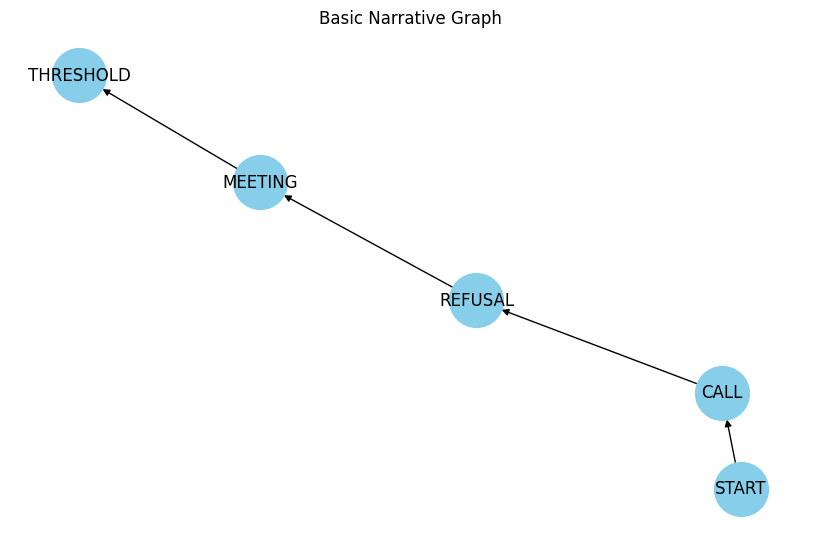

In [ ]:
plt.figure(figsize=(8, 5))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=1500, font_size=12)
plt.title("Basic Narrative Graph")
plt.show()

### 3. 커스텀 시각화 (스타일 적용)
노드 속성에 따른 색상 지정 및 엣지 라벨을 추가하여 시인성을 높입니다.

/home/torious/anaconda3/envs/modulab1/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/home/torious/anaconda3/envs/modulab1/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/home/torious/anaconda3/envs/modulab1/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/home/torious/anaconda3/envs/modulab1/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/home/torious/anaconda3/envs/modulab1/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing 

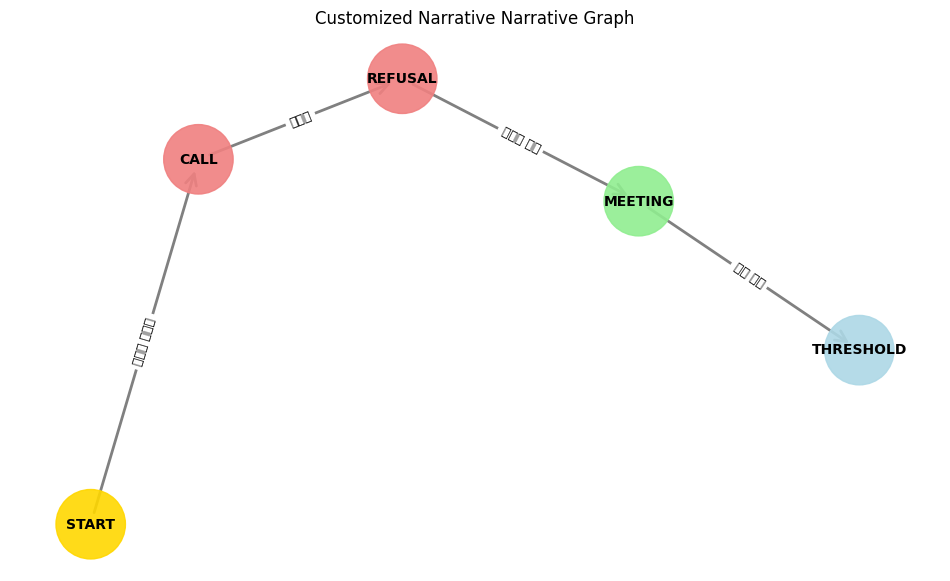

In [ ]:
plt.figure(figsize=(12, 7))
pos = nx.spring_layout(G, seed=42)  # 레이아웃 고정

# 노드 유형별 색상 매핑
color_map = {
    "origin": "gold",
    "incident": "lightcoral",
    "growth": "lightgreen",
    "action": "lightblue"
}
node_colors = [color_map.get(G.nodes[node].get('metadata', {}).get('type'), 'grey') for node in G.nodes()]

# 노드 그리기
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, alpha=0.9)

# 라벨 그리기
nx.draw_networkx_labels(G, pos, font_size=10, font_family='NanumGothic', font_weight='bold')

# 엣지 그리기
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=2)

# 엣지 라벨(설명) 추가
edge_labels = nx.get_edge_attributes(G, 'description')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Customized Narrative Narrative Graph")
plt.axis('off')
plt.show()

### 4. 다양한 레이아웃 비교
동일한 그래프를 다양한 레이아웃으로 시각화해 봅니다.

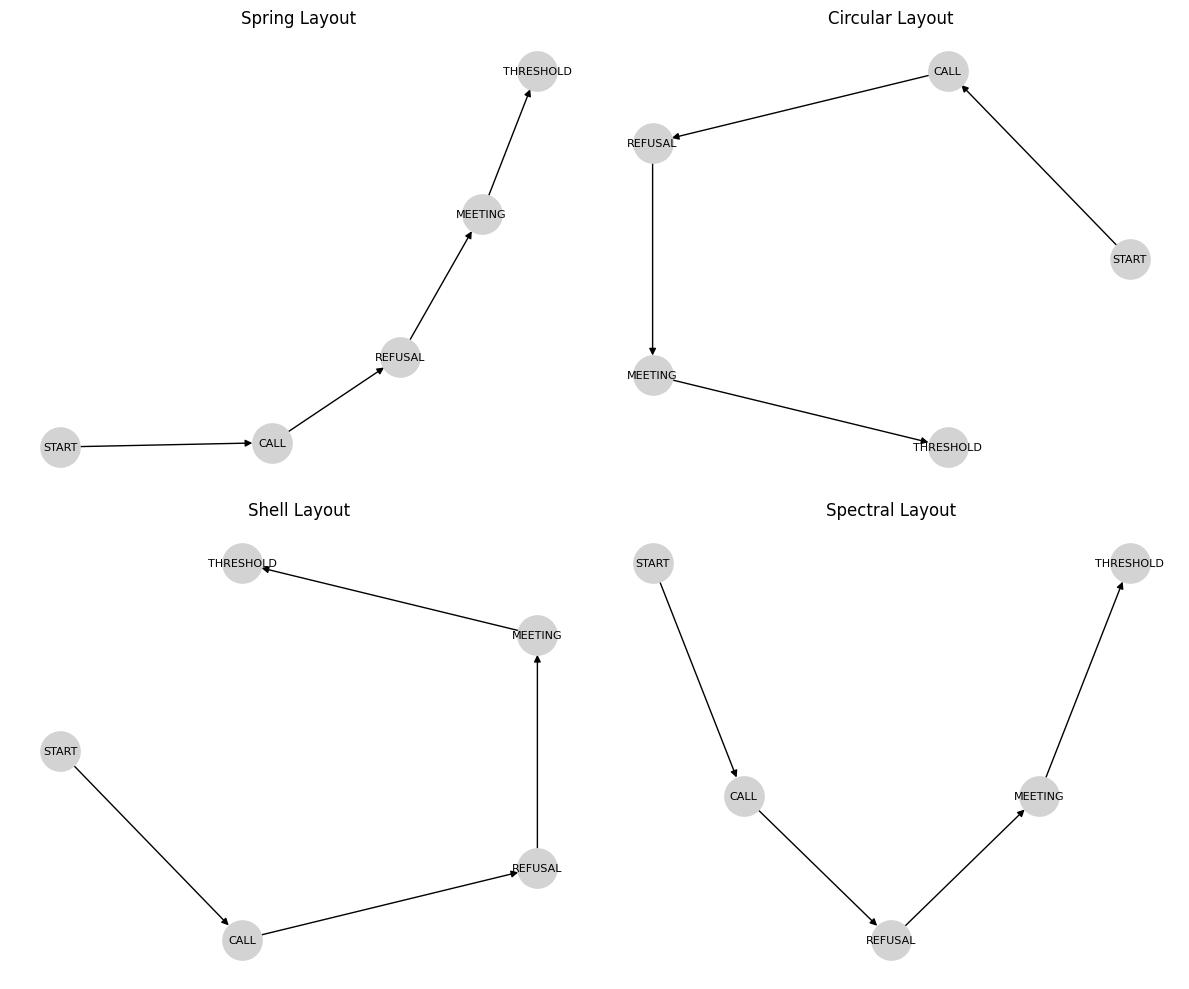

In [ ]:
layouts = {
    "Spring": nx.spring_layout(G),
    "Circular": nx.circular_layout(G),
    "Shell": nx.shell_layout(G),
    "Spectral": nx.spectral_layout(G)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, pos) in zip(axes, layouts.items()):
    nx.draw(G, pos, ax=ax, with_labels=True, node_color='lightgrey', node_size=800, font_size=8)
    ax.set_title(f"{name} Layout")

plt.tight_layout()
plt.show()